# 0 Imports

In [12]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import umap.umap_ as umap

import pandas as pd
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn import metrics as m
from yellowbrick.cluster import SilhouetteVisualizer

from src.suporte import funcoes_suporte as fs

## 0.1 Funções Suporte

In [13]:
fs.jupyter_settings(altura = 10, largura = 16, fonte = 8)
fs.supressao_notacao(casa_decimal = 2)

# 0.2 Load Data

In [14]:
df = fs.load_pickle('../data/processed/8.data_model_training.pkl')
df.sample(5)

,customer_id,faturamento,recencia_days,qtde_compras,qtde_produto_comprado,avg_faturamento,avg_recency_days,frequencia,retornos,clusters
728,17611,3984.22,7,15,272,6.92,27.23,0.04,4.00,1
3230,16283,1569.11,5,5,298,9.51,50.75,0.02,2.00,1
3912,13207,250.26,15,2,70,31.28,135.00,0.01,0.00,3
39,16210,21076.30,1,17,2685,172.76,24.80,0.05,0.00,1
3657,17299,669.11,11,4,252,11.74,54.00,0.02,0.00,1


In [15]:
df_run = df.drop(columns=['customer_id','clusters'])
df_run.head()

,faturamento,recencia_days,qtde_compras,qtde_produto_comprado,avg_faturamento,avg_recency_days,frequencia,retornos
0,5391.21,372,34,35,18.15,1.00,17.00,1.00
1,3232.59,56,9,131,18.90,52.83,0.03,7.00
2,6705.38,2,15,1568,28.90,26.50,0.04,2.00
3,948.25,95,5,169,33.87,92.67,0.02,0.00
4,876.00,333,3,48,292.00,20.00,0.07,3.00


## 0.3 Load Model

In [16]:
kmeans = fs.load_pickle('../models/8.model_training.pkl')

# 1. Análise

## 1.1. Visualizações

e:\3_recursos\2_area\profissional\cursos\26_04_1-Fidelidade_Clusterizacao\cluster\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


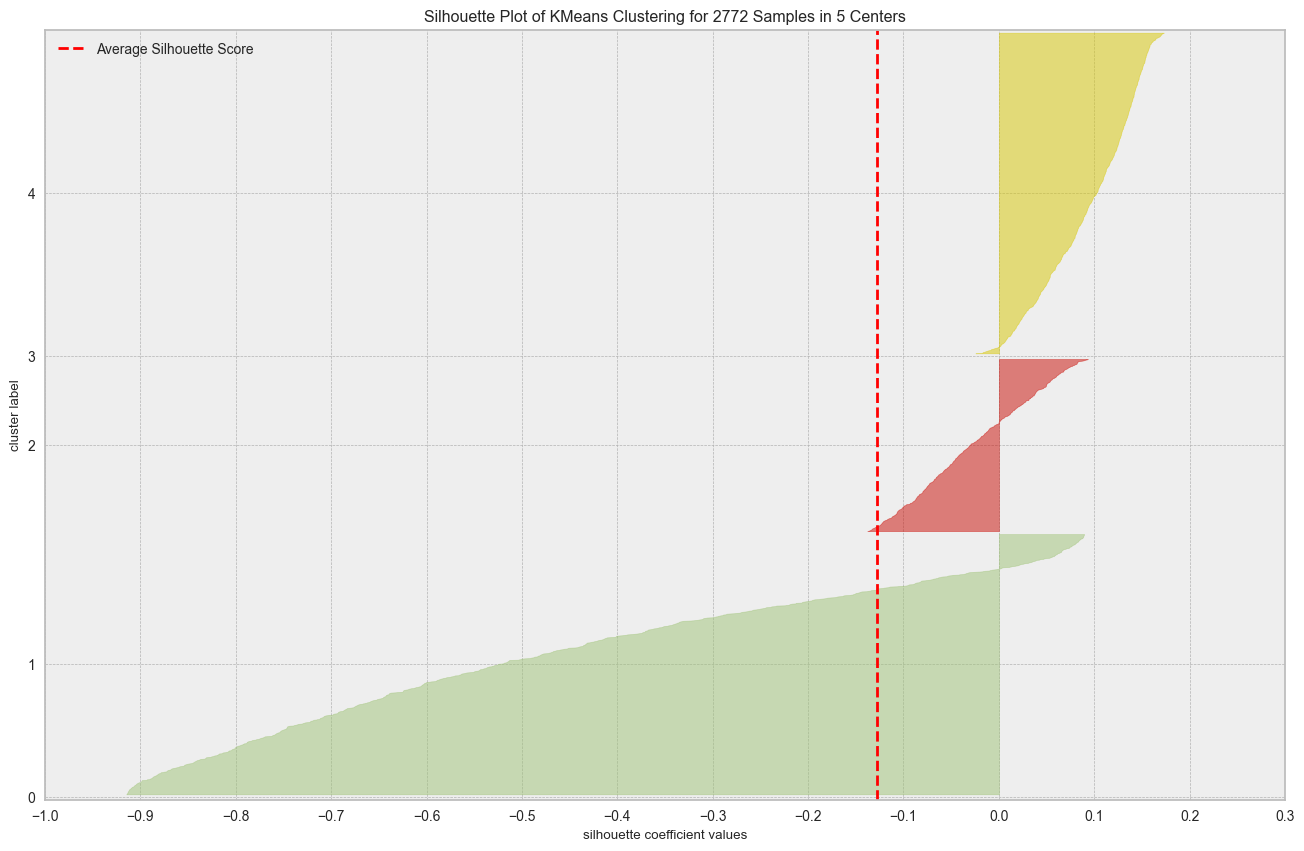

In [17]:
visualiser = SilhouetteVisualizer(kmeans, colors = 'yellowbrick', force_model=True)
visualiser.fit(df_run)
visualiser.finalize()

## 1.1.2 2D plot

In [18]:
df_run2 = df.drop(columns=['customer_id'])
df_run2.head()

,faturamento,recencia_days,qtde_compras,qtde_produto_comprado,avg_faturamento,avg_recency_days,frequencia,retornos,clusters
0,5391.21,372,34,35,18.15,1.00,17.00,1.00,2
1,3232.59,56,9,131,18.90,52.83,0.03,7.00,1
2,6705.38,2,15,1568,28.90,26.50,0.04,2.00,1
3,948.25,95,5,169,33.87,92.67,0.02,0.00,0
4,876.00,333,3,48,292.00,20.00,0.07,3.00,2


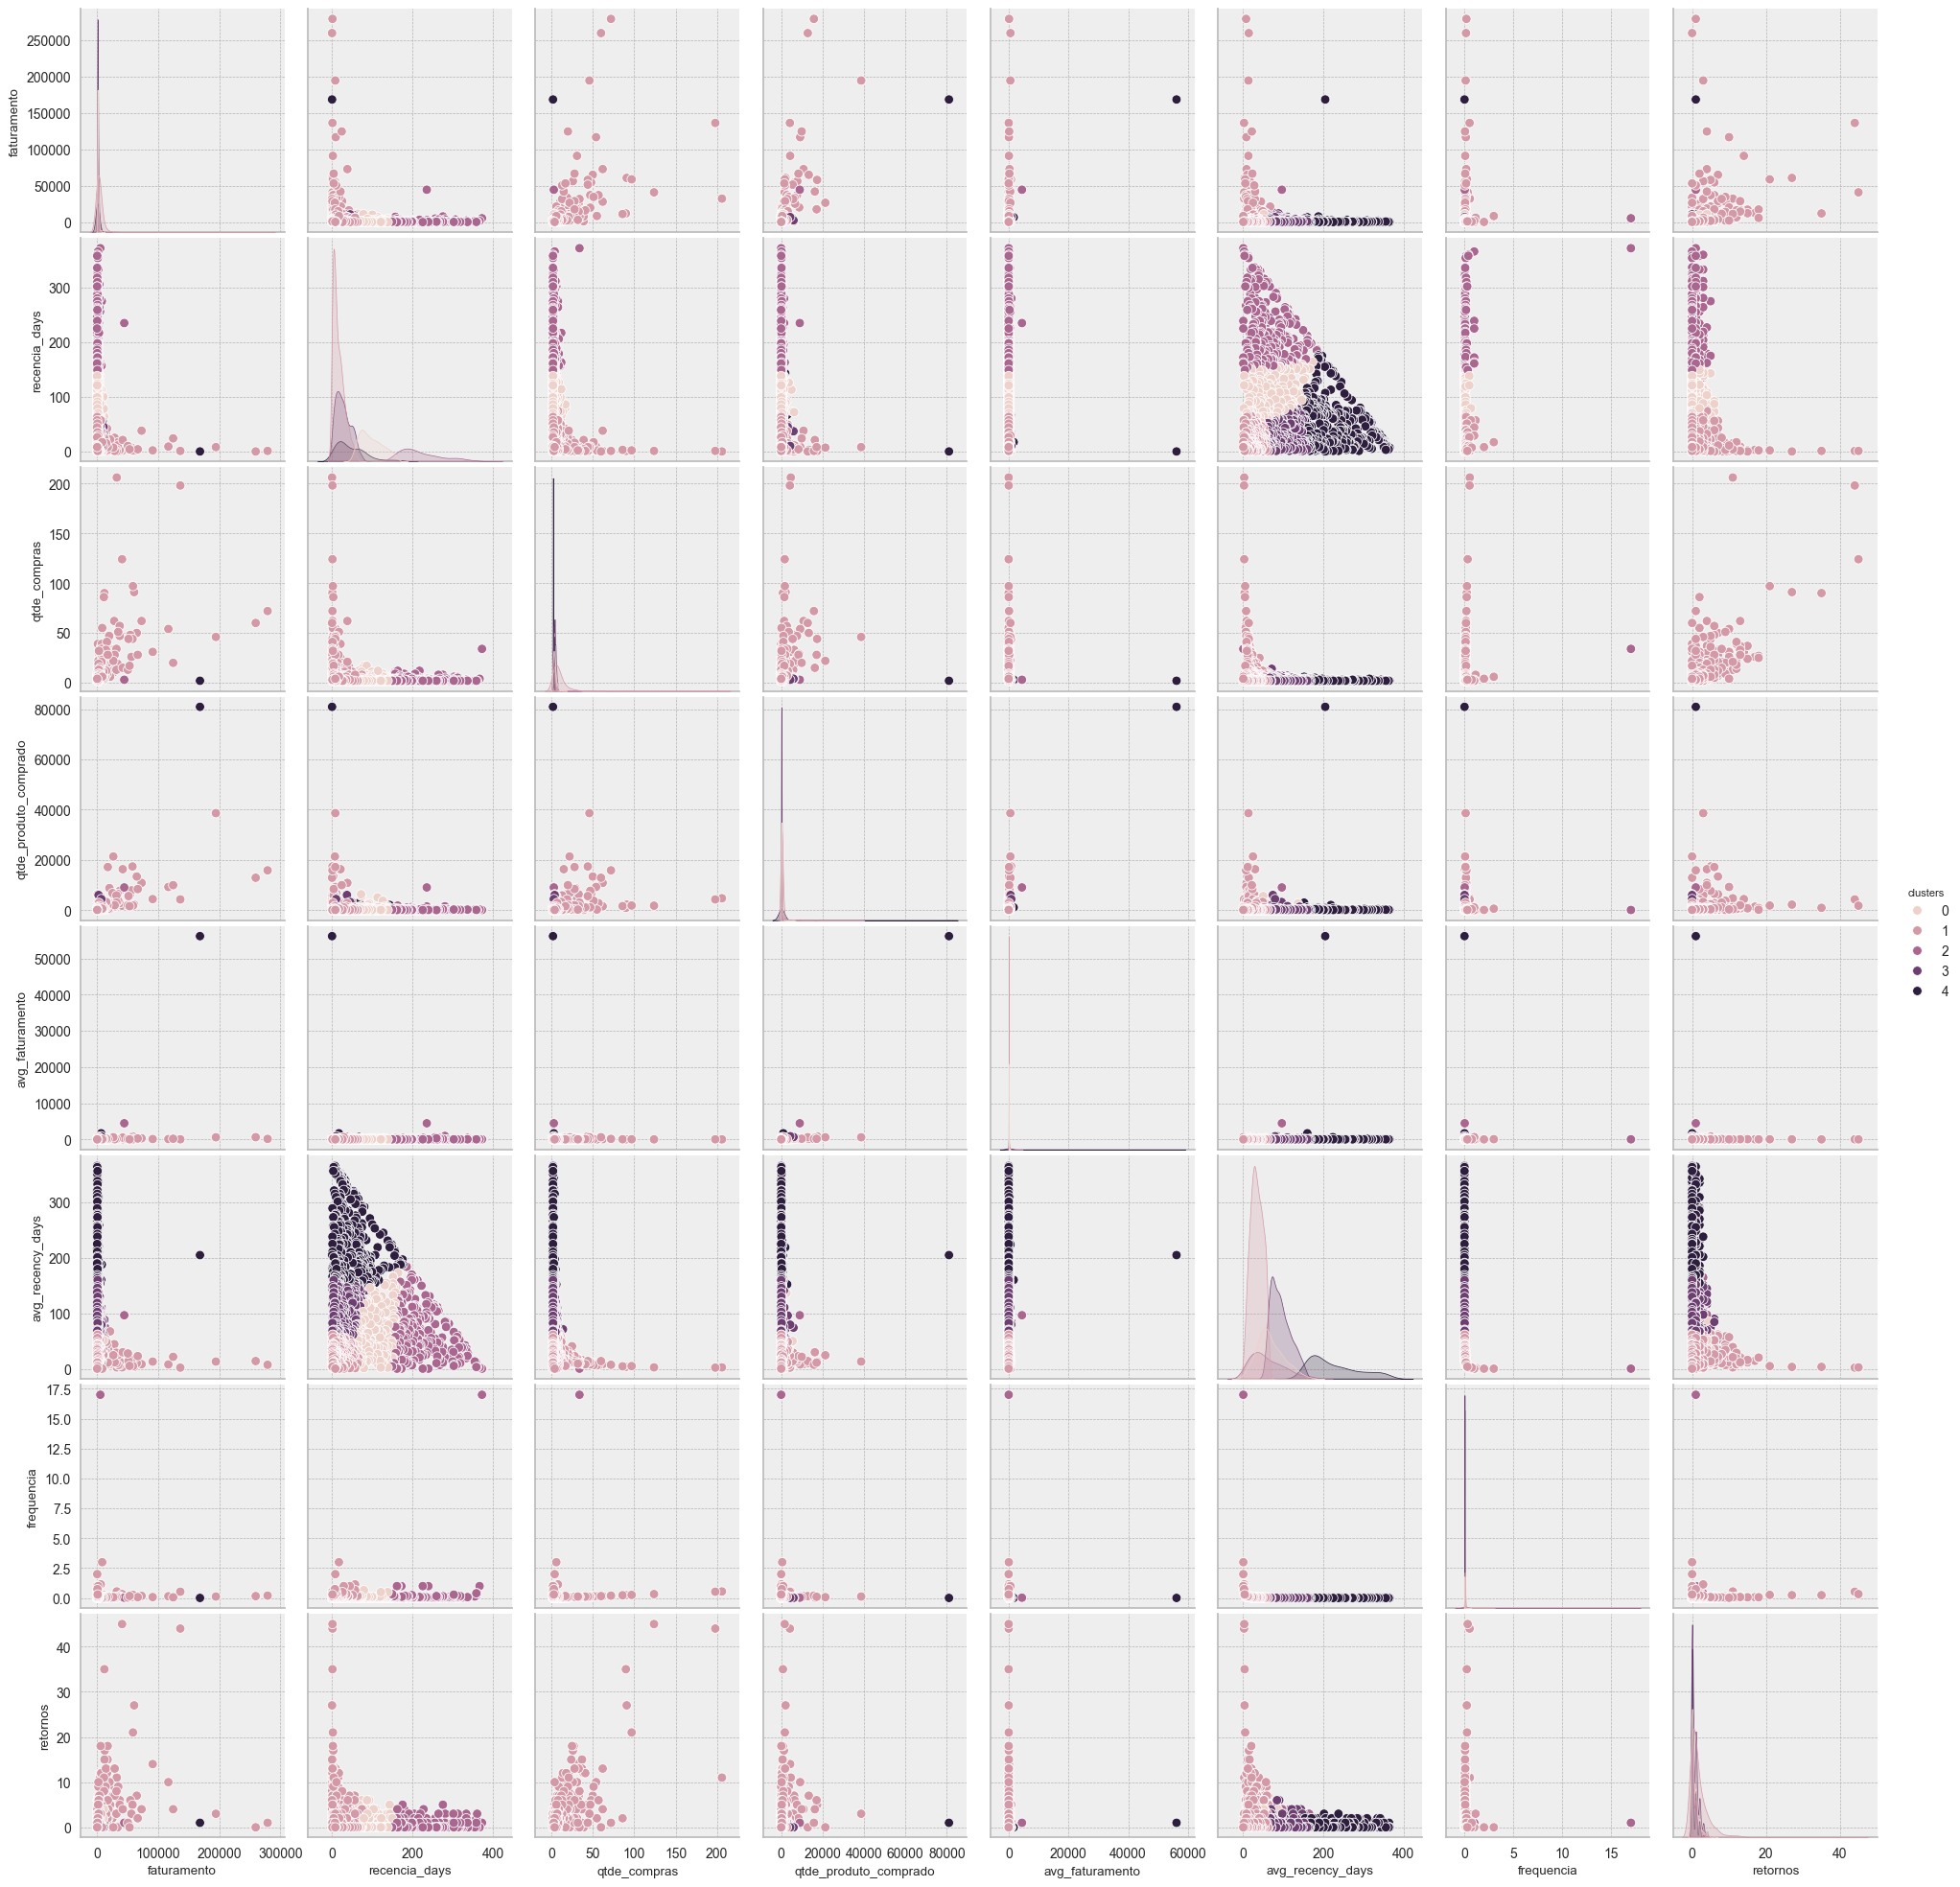

In [19]:
sns.pairplot(df_run2, hue='clusters')

### 3D Plot

In [20]:
#fig = px.scatter_3d(df, x='recencia_days', y='invoice_no', z='faturamento', color='clusters')
#fig.show()

## 1.2 UMAP - t-SNE

### 1.2.1 UMAP 2d

e:\3_recursos\2_area\profissional\cursos\26_04_1-Fidelidade_Clusterizacao\cluster\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='embedding_2d_x', ylabel='embedding_2d_y'>

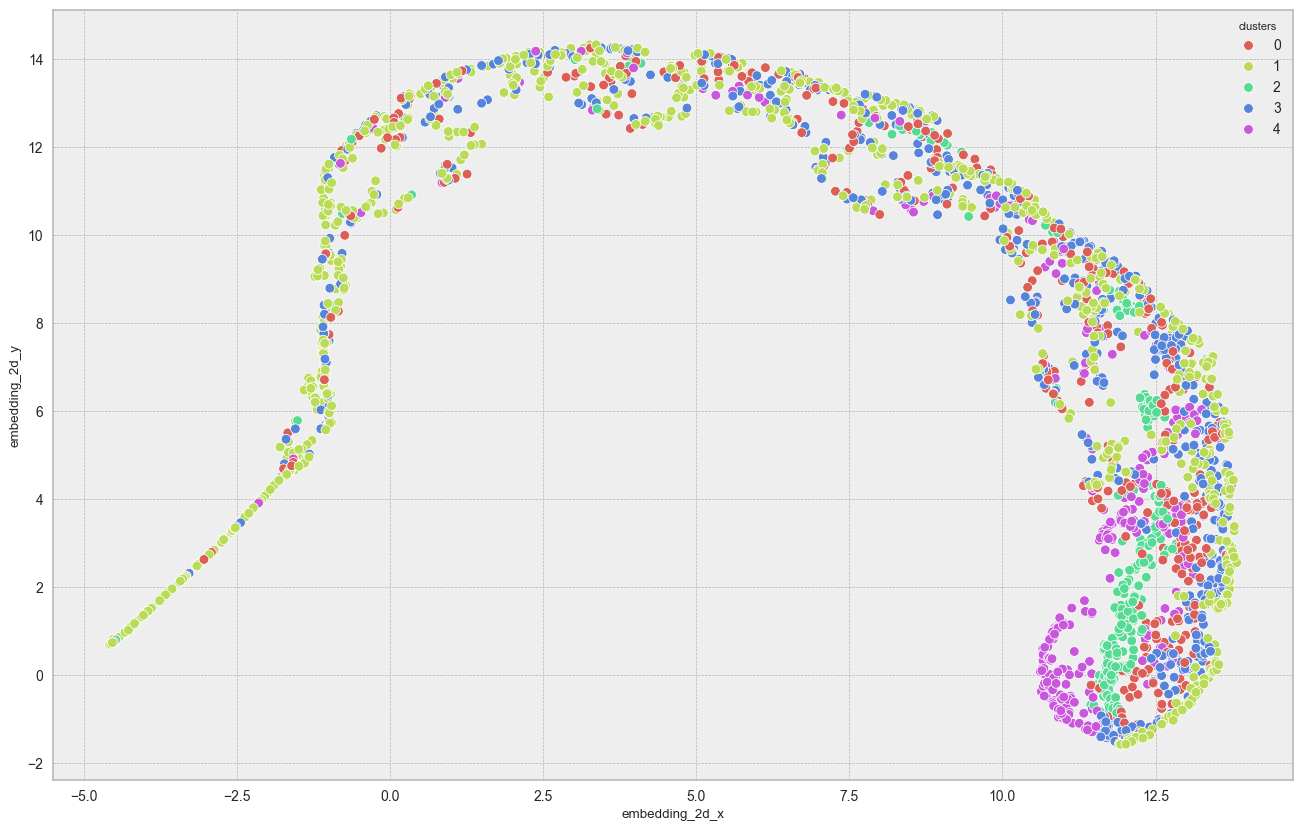

In [21]:
reducer = umap.UMAP(n_neighbors=40, random_state = 42)
embedding = reducer.fit_transform(df_run2)

df_run2['embedding_2d_x'] = embedding [:,0]
df_run2['embedding_2d_y'] = embedding [:,1]

sns.scatterplot(x='embedding_2d_x',y='embedding_2d_y',
                hue = 'clusters',
                palette=sns.color_palette('hls', n_colors=len(df_run2['clusters'].unique() ) ),
                data = df_run2)

### 1.2.2 UMAP 3d

In [22]:
reducer = umap.UMAP(n_components=3, n_neighbors=40, random_state = 42)
embedding = reducer.fit_transform(df_run2)

df_run2['embedding_3d_x'] = embedding [:,0]
df_run2['embedding_3d_y'] = embedding [:,1]
df_run2['embedding_3d_z'] = embedding [:,2]

fig = px.scatter_3d(df_run2, x='embedding_3d_x',y='embedding_3d_y',z='embedding_3d_z',
                    color=df_run2['clusters'].astype(str))
fig.show()

e:\3_recursos\2_area\profissional\cursos\26_04_1-Fidelidade_Clusterizacao\cluster\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Ficou tão feio.... peia pouca num presta, só presta peia muita....

No começo tava bom. Disseram que ia melhorar. Já não ficou muito bom. Agora parece que piorou

## 1.3. Cluster Profile

In [20]:
# Numero de Pessoas
df_cluster = df[['customer_id', 'clusters']].groupby('clusters').count().reset_index()
df_cluster['perc_customer'] = 100*(df_cluster['customer_id']/df_cluster['customer_id'].sum())

# Média Faturamento
df_media_faturamento = df[['faturamento', 'clusters']].groupby('clusters').mean().reset_index()
df_cluster = pd.merge(df_cluster, df_media_faturamento, how='inner', on="clusters")

# Média Recencia
df_media_faturamento = df[['recencia_days', 'clusters']].groupby('clusters').mean().reset_index()
df_cluster = pd.merge(df_cluster, df_media_faturamento, how='inner', on="clusters")

# Média Frequencia
df_media_faturamento = df[['frequencia', 'clusters']].groupby('clusters').mean().reset_index()
df_cluster = pd.merge(df_cluster, df_media_faturamento, how='inner', on="clusters")

# Média Ticket
df_ticket = df[['avg_faturamento','clusters']].groupby('clusters').mean().reset_index()
df_cluster = pd.merge(df_cluster, df_ticket, how='inner', on="clusters")

df_cluster

,clusters,customer_id,perc_customer,faturamento,recencia_days,frequencia,avg_faturamento
0,0,1147,26.50,1302.80,13.41,3.92,29.88
1,1,482,11.13,10263.92,12.62,16.27,156.88
2,2,1445,33.38,1027.45,61.08,2.74,27.98
3,3,1255,28.99,662.20,230.54,1.67,114.84


Cluster 01: ( Candidato à Insider )
 - Número de customers: 6 (0,14% do customers)
 - Recência em média: 7 dias
 - Compras em média: 89 compras
 - Receita em média: $182.182,00 dólares

Cluster 02:
 - Número de customers: 31 (0,71% do customers)
 - Recência em média: 14 dias
 - Compras em média: 53 compras
 - Receita em média: $40.543,52 dólares

Cluster 03:
 - Número de customers: 4.335 (99% do customers)
 - Recência em média: 92 dias
 - Compras em média: 5 compras
 - Receita em média: $1.372,57 dólares